In [5]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from keras.datasets import fashion_mnist
from keras.models import Sequential
from keras.layers import Dense, Flatten, Input, Conv2D, MaxPool2D, Conv2DTranspose
from keras.losses import MeanSquaredError
from keras.optimizers import AdamW

import matplotlib.pyplot as plt

In [26]:
(x_train, _), (x_test, _) = fashion_mnist.load_data()

print(f"Shape of training set: {x_train.shape}")
print(f"Shape of test set: {x_test.shape}")

Shape of training set: (60000, 28, 28)
Shape of test set: (10000, 28, 28)


In [27]:
x_train = x_train.astype(np.float32) / 255
x_test = x_test.astype(np.float32) / 255

x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]

In [ ]:
class ConvAutoEncoder(keras.Model):
    def __init__(self, ):
        super().__init__()
        
        self.encoder = Sequential([
            Conv2D(16, kernel_size=(3, 3), activation='relu', padding='same', strides=2),    # (14, 14, 16)
            Conv2D(8, kernel_size=(3, 3), activation='relu', padding='same', strides=2),    # (7, 7, 8)
        ])

        self.decoder = Sequential([
            # Conv2DTranspose(8, kernel_size=(3, 3), activation='relu', padding='same', strides=2),   # (14, 14, 8)
            Conv2DTranspose(16, kernel_size=(3, 3), activation='relu', padding='same', strides=2),  # (14, 14, 16)
            Conv2DTranspose(1, kernel_size=(3, 3), activation='sigmoid', padding='same', strides=2),   # (28, 27, 1)
        ])

    def call(self, inputs):
        encod = self.encoder(inputs)
        decod = self.decoder(encod)

        return decod

In [20]:
model = ConvAutoEncoder()

In [21]:
model(x_train[0].reshape(-1, 28, 28, 1))

<tf.Tensor: shape=(1, 28, 28, 1), dtype=float32, numpy=
array([[[[0.5       ],
         [0.5       ],
         [0.5       ],
         [0.5       ],
         [0.5       ],
         [0.5       ],
         [0.5       ],
         [0.5       ],
         [0.49978626],
         [0.49977666],
         [0.49990612],
         [0.4996379 ],
         [0.49817443],
         [0.49815527],
         [0.49935377],
         [0.49719688],
         [0.49671888],
         [0.4970769 ],
         [0.49835473],
         [0.49694765],
         [0.499583  ],
         [0.4986929 ],
         [0.49964285],
         [0.4991989 ],
         [0.49949288],
         [0.49931842],
         [0.5004396 ],
         [0.49970287]],

        [[0.5       ],
         [0.5       ],
         [0.5       ],
         [0.5       ],
         [0.5       ],
         [0.5       ],
         [0.5       ],
         [0.5       ],
         [0.49977905],
         [0.4998722 ],
         [0.49984512],
         [0.49999976],
         [0.49819994],

In [22]:
model.encoder.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (1, 14, 14, 16)        │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (1, 7, 7, 8)           │         1,160 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,320 (5.16 KB)

 Trainable params: 1,320 (5.16 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
model.decoder.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_transpose_8              │ (1, 14, 14, 16)        │         1,168 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_9              │ (1, 28, 28, 1)         │           145 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,313 (5.13 KB)

 Trainable params: 1,313 (5.13 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
# Add Normal noise
noise_factor = 0.2

x_train_noisy = x_train + noise_factor * tf.random.normal(shape=x_train.shape)    # -0.2 - 1.2
x_test_noisy = x_test + noise_factor * tf.random.normal(shape=x_test.shape)

x_train_noisy = tf.clip_by_value(x_train_noisy, clip_value_min=0., clip_value_max=1.0)
x_test_noisy = tf.clip_by_value(x_test_noisy, clip_value_min=0., clip_value_max=1.0)

Text(0.5, 1.0, 'Noisy Image')

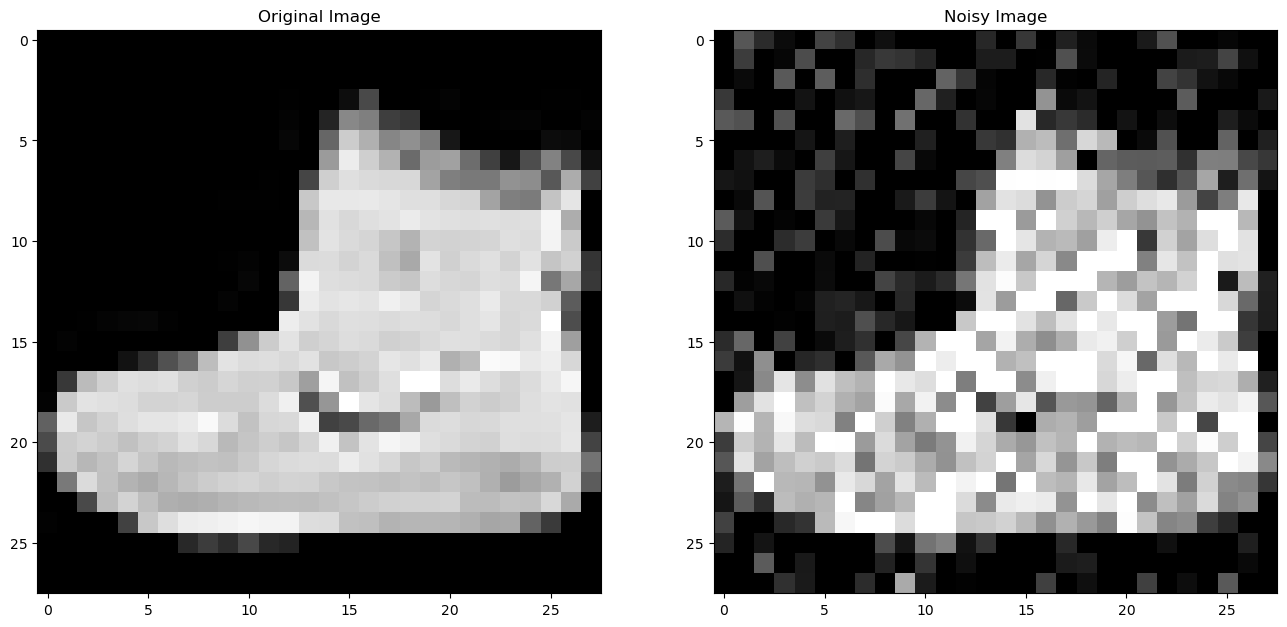

In [37]:
plt.figure(figsize=(16, 8))

plt.subplot(1, 2, 1); plt.imshow(x_train[0], cmap='gray'); plt.title('Original Image')
plt.subplot(1, 2, 2); plt.imshow(x_train_noisy[0], cmap='gray'); plt.title("Noisy Image")

In [35]:
assert x_train[0][19, 15] == x_train_noisy[0][19, 15]

In [29]:
model.compile(optimizer=AdamW(learning_rate=0.001),
              loss=MeanSquaredError)

In [30]:
model.fit(x_train_noisy, x_train, validation_split=0.2, epochs=30, batch_size=128)

Epoch 1/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0399 - val_loss: 0.0122
Epoch 2/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0097 - val_loss: 0.0076
Epoch 3/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0063 - val_loss: 0.0055
Epoch 4/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0051 - val_loss: 0.0048
Epoch 5/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0045 - val_loss: 0.0043
Epoch 6/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0041 - val_loss: 0.0039
Epoch 7/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0038 - val_loss: 0.0037
Epoch 8/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0036 - val_loss: 0.0035
Epoch 9/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0034 - val_loss: 0.0033
Epoch 10/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0033 - val_loss: 0.0032
Epoch 11/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0032 - val_loss: 0.0031
Epoch 12/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step

In [45]:
predicted = model(x_test_noisy[0:1])
print(predicted.shape)

(1, 28, 28, 1)


Text(0.5, 1.0, 'Denoised Image')

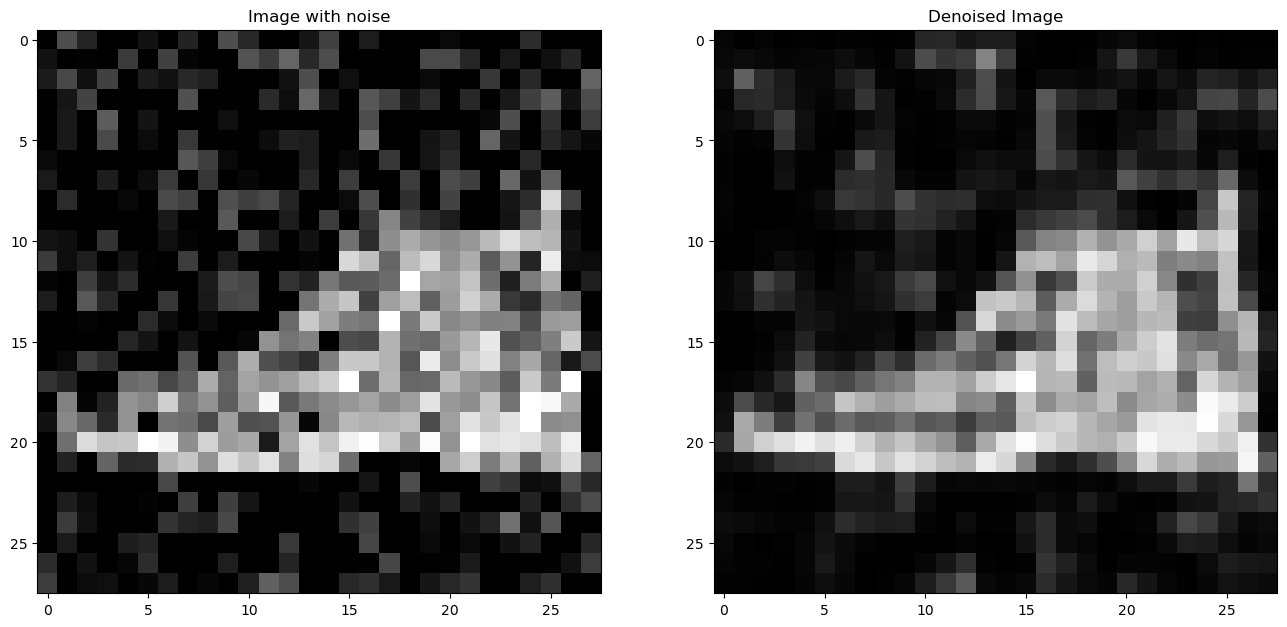

In [48]:
plt.figure(figsize=(16, 8))

plt.subplot(1, 2, 1); plt.imshow(x_test_noisy[0], cmap='gray'); plt.title('Image with noise')
plt.subplot(1, 2, 2); plt.imshow(predicted[0], cmap='gray'); plt.title("Denoised Image")

In [49]:
encod_image = model.encoder(x_test_noisy[0:1])